In [1]:
import os

# Inspect input directory contents
input_base = '/kaggle/input'
print("Datasets available:", os.listdir(input_base))

# Locate the root dataset directory
dataset_folder_name = os.listdir(input_base)[0]
base_path = os.path.join(input_base, dataset_folder_name)

# If the folders are nested inside an inner folder, search for Dataset/train
if os.path.exists(os.path.join(base_path, 'Dataset')):
    dataset_dir = os.path.join(base_path, 'Dataset')
elif os.path.exists(os.path.join(base_path, 'dataset')):
    dataset_dir = os.path.join(base_path, 'dataset')
else:
    # Check if nested within another subdirectory
    subdirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    dataset_dir = subdirs[0] if subdirs else base_path

train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')

print("Resolved paths:")
print(" Train:", train_dir)
print(" Val:  ", val_dir)
print(" Test: ", test_dir)

Datasets available: ['datasets']
Resolved paths:
 Train: /kaggle/input/datasets/oshadafernando/train
 Val:   /kaggle/input/datasets/oshadafernando/val
 Test:  /kaggle/input/datasets/oshadafernando/test


In [2]:
import os

# Search the entire Kaggle input directory for the exact folder locations
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'val' in dirs and 'test' in dirs:
        print("Found them! Replace your variables in Cell 2 with these exact paths:\n")
        print(f"train_dir = '{os.path.join(root, 'train')}'")
        print(f"val_dir = '{os.path.join(root, 'val')}'")
        print(f"test_dir = '{os.path.join(root, 'test')}'")
        break
else:
    print("Could not find the train/val/test folders. Check the 'Input' panel on the right to ensure the dataset is attached.")

Found them! Replace your variables in Cell 2 with these exact paths:

train_dir = '/kaggle/input/datasets/oshadafernando/deep-learning-image-classification/Deep-Learning-Image-Classification/Dataset/train'
val_dir = '/kaggle/input/datasets/oshadafernando/deep-learning-image-classification/Deep-Learning-Image-Classification/Dataset/val'
test_dir = '/kaggle/input/datasets/oshadafernando/deep-learning-image-classification/Deep-Learning-Image-Classification/Dataset/test'


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Exact paths verified by the search script
train_dir = '/kaggle/input/datasets/oshadafernando/deep-learning-image-classification/Deep-Learning-Image-Classification/Dataset/train'
val_dir = '/kaggle/input/datasets/oshadafernando/deep-learning-image-classification/Deep-Learning-Image-Classification/Dataset/val'
test_dir = '/kaggle/input/datasets/oshadafernando/deep-learning-image-classification/Deep-Learning-Image-Classification/Dataset/test'

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 1. Training Generator with Data Augmentation and Rescaling
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# 2. Validation and Test Generator (Strictly Rescaling only)
test_val_datagen = ImageDataGenerator(rescale=1.0 / 255)

# 3. Create Dataset Iterators
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nLoading Validation Data:")
validation_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nLoading Test Data:")
test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass Mapping:", train_generator.class_indices)

Loading Training Data:
Found 12632 images belonging to 6 classes.

Loading Validation Data:
Found 1402 images belonging to 6 classes.

Loading Test Data:
Found 3000 images belonging to 6 classes.

Class Mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Load VGG16 base without ImageNet top classification layer
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base feature extraction layers
base_model.trainable = False

# Construct final network
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.summary()

I0000 00:00:1790267762.606655      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790267762.609841      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
import time
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping to prevent overfitting and unnecessary iterations
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Starting VGG16 model training...")
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

end_time = time.time()
training_duration_minutes = (end_time - start_time) / 60
print(f"\nTotal Training Duration: {training_duration_minutes:.2f} minutes")

# Save model artifact to Kaggle output space
model.save('/kaggle/working/vgg16_final_model.h5')
print("Model saved to /kaggle/working/vgg16_final_model.h5")

Starting VGG16 model training...
Epoch 1/15
  1/395 ━━━━━━━━━━━━━━━━━━━━ 1:47:17 16s/step - accuracy: 0.3438 - loss: 2.3000

I0000 00:00:1790267782.604477      90 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


395/395 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - accuracy: 0.6634 - loss: 0.9028 - val_accuracy: 0.8210 - val_loss: 0.4963
Epoch 2/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 198s 500ms/step - accuracy: 0.7306 - loss: 0.6934 - val_accuracy: 0.8588 - val_loss: 0.4179
Epoch 3/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 192s 485ms/step - accuracy: 0.7440 - loss: 0.6679 - val_accuracy: 0.8352 - val_loss: 0.4525
Epoch 4/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 193s 487ms/step - accuracy: 0.7557 - loss: 0.6330 - val_accuracy: 0.8466 - val_loss: 0.4240
Epoch 5/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 191s 484ms/step - accuracy: 0.7707 - loss: 0.5983 - val_accuracy: 0.8716 - val_loss: 0.3712
Epoch 6/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 191s 483ms/step - accuracy: 0.7682 - loss: 0.6036 - val_accuracy: 0.8723 - val_loss: 0.3957
Epoch 7/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 190s 480ms/step - accuracy: 0.7774 - loss: 0.5806 - val_accuracy: 0.8787 - val_loss: 0.3540
Epoch 8/15
395/395 ━━━━━━━━━━━━━━━━━━━━ 209s 529ms/step - accuracy: 0.7817 - loss: 0.5719 


Total Training Duration: 42.77 minutes
Model saved to /kaggle/working/vgg16_final_model.h5


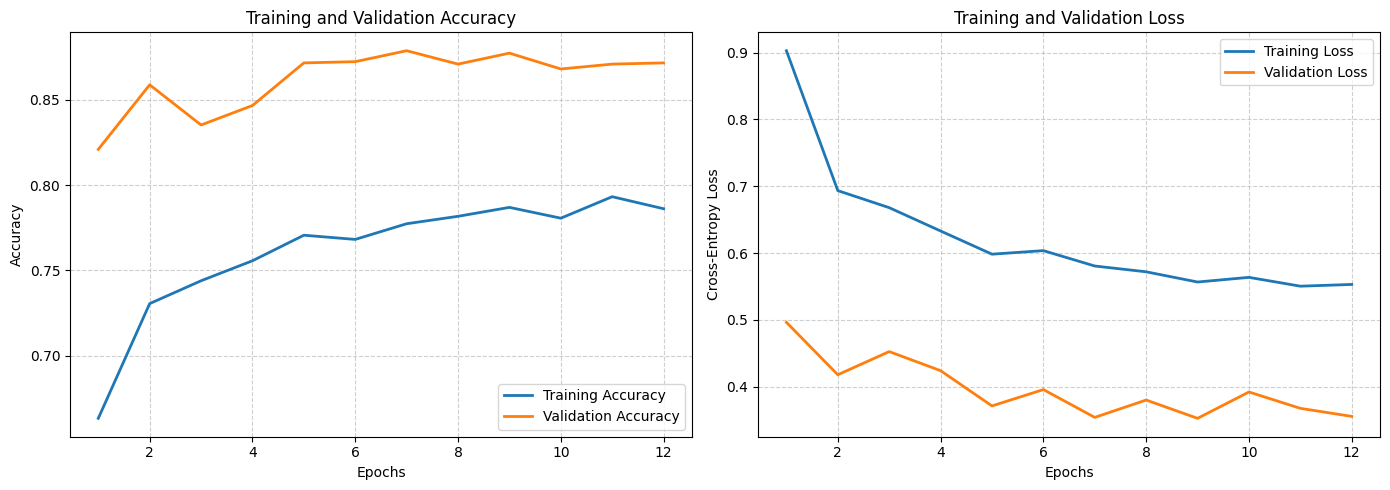

In [6]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.title('Training and Validation Accuracy', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Training and Validation Loss', fontsize=12)
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('/kaggle/working/vgg16_learning_curves.png', dpi=300)
plt.show()

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Generating predictions on unseen test dataset...")
test_generator.reset()

y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

test_acc = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='macro')
test_recall = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print("\n--- Model Performance on Test Set ---")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1-Score:  {test_f1:.4f}")

Generating predictions on unseen test dataset...
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 339ms/step

--- Model Performance on Test Set ---
Test Accuracy:  0.8757
Macro Precision: 0.8784
Macro Recall:    0.8785
Macro F1-Score:  0.8781


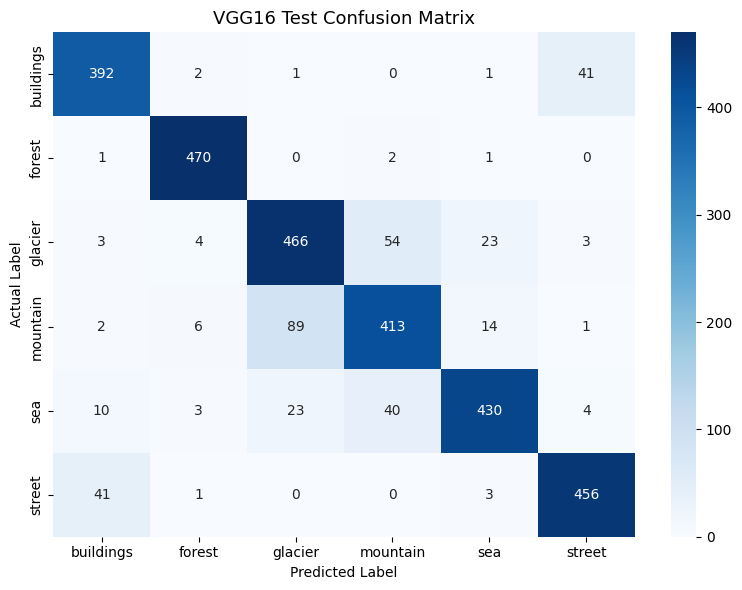

In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('VGG16 Test Confusion Matrix', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/kaggle/working/vgg16_confusion_matrix.png', dpi=300)
plt.show()